In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_excel('/content/Dataset.xlsx')
df.head()

,Text before,Label
0,سيدي، أعلم أنك يجب أن تكون قد وصلت الرسالة الأ...,Phishing
1,سيدي العزيز، نود أن ننقل إلى حساب ما وراء البح...,Phishing
2,على الرغم من أنني أعلم أن معاملة بهذا الحجم ست...,Phishing
3,سيدي العزيز، أنا سام ألوكو، المستشار الخاص الس...,Phishing
4,أرجو أن تسمحوا لي بتواضع تقديم نفسي=2E أنا جور...,Phishing


In [ ]:
df['Text before'][0]

'سيدي، أعلم أنك يجب أن تكون قد وصلت الرسالة الأولى التي أرسلتها إليك عن طريق البريد، لكن إن لم يكن، هنا يأتي متابعة للرسالة. أولاً، يجب أن أرى من أجل فهمكخلال فترة التحقيق الذي نقوم به في إطار التحقيق الذي نقوم به في إطارلقد اعتقدنا أنه في أقرب وقت نرسل لك رسالـة مرفـقـك خـلال الرسالـة التـي نرسلهـا خـلال الرسالـة التـي نرسلها خـلال الرسالـة الإلكترونيـة الـماثلة التي نرسلها دون مقابل إلى تحويل هذه الكمية من دولارات الولايات المتحدة إلى هذا العدد. لقد قررنا أنه في أقرب وقت نرسل رسالتـك الرسالـة التي تتضمن الرسالة التي ترسلها إليك في 14 يوم عمل. وقد اتفقنا على أنه من أجل المساعدة التي نقدمها، سنقدمها لك، وسنحصل على أكثر من 60 و 10 في المائة للإضافات التي قد نزيدها.هذا البريد الإلكتروني. يرجى إدراج رقم الهاتف الخصوصي الخاص بك ورقم الفاكس الخاص بالاتصالات السريعة، والقيام بتوبيخي من خلال خطابي الخاص والواثق بشأن أسباب الأمن: Frank@senate Contractgrammevervifictioncomite.zn.com, covers, and peshed Bless.'

In [ ]:
df['Label'].unique()

array(['Phishing', 'phishing', 'Non_Phishing', nan], dtype=object)

In [ ]:
df['Label'].isna().sum()

1

In [ ]:
df.shape

(2404, 2)

In [ ]:
df = df.dropna(subset=['Label'])

In [ ]:
df.shape

(2403, 2)

In [ ]:
df.groupby('Label').count()

,Text before
Label,
Non_Phishing,1574
Phishing,828
phishing,1


In [ ]:
df['Label'] = df['Label'].str.lower().replace({'phishing': 'Phishing'})

In [ ]:
df.groupby('Label').count()

,Text before
Label,
Phishing,829
non_phishing,1574


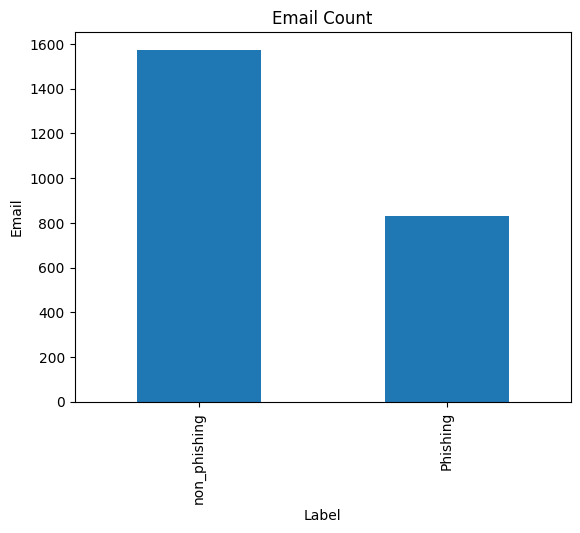

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


label_counts = df['Label'].value_counts()
label_counts.plot(kind='bar')
plt.title('Email Count')
plt.xlabel('Label')
plt.ylabel('Email')
plt.show()

In [ ]:
import pandas as pd
import re

stopwords_df = pd.read_excel('/content/Stopwords arabic.xlsx')
stopwords = stopwords_df['words'].tolist()

def clean_arabic_text(text, stopwords):
    text = re.sub(r'[^\w\s]', '', text)

    text = re.sub(r'[^\u0600-\u06FF\s]', '', text)

    words = text.split()


    words = [word for word in words if word not in stopwords]


    cleaned_text = ' '.join(words)

    return cleaned_text

df['Cleaned Text'] = df['Text before'].apply(lambda x: clean_arabic_text(x, stopwords))

print(df[['Text before', 'Cleaned Text']].head())

                                         Text before  \
0  سيدي، أعلم أنك يجب أن تكون قد وصلت الرسالة الأ...   
1  سيدي العزيز، نود أن ننقل إلى حساب ما وراء البح...   
2  على الرغم من أنني أعلم أن معاملة بهذا الحجم ست...   
3  سيدي العزيز، أنا سام ألوكو، المستشار الخاص الس...   
4  أرجو أن تسمحوا لي بتواضع تقديم نفسي=2E أنا جور...   

                                        Cleaned Text  
0  سيدي أعلم أنك يجب أن تكون وصلت الرسالة الأولى ...  
1  سيدي العزيز نود أن ننقل إلى حساب وراء البحار د...  
2  الرغم أنني أعلم أن معاملة بهذا الحجم ستجعل أي ...  
3  سيدي العزيز أنا سام ألوكو المستشار الخاص المعن...  
4  أرجو أن تسمحوا لي بتواضع تقديم نفسي أنا جورج ك...  


In [ ]:
df.shape

(2403, 3)

In [ ]:
df['Cleaned Text'][0]

'سيدي أعلم أنك يجب أن تكون وصلت الرسالة الأولى أرسلتها إليك طريق البريد إن يكن هنا يأتي متابعة للرسالة أولا يجب أن أرى أجل فهمكخلال فترة التحقيق نقوم به إطار التحقيق نقوم به إطارلقد اعتقدنا أنه أقرب وقت نرسل لك رسالـة مرفـقـك خـلال الرسالـة التـي نرسلهـا خـلال الرسالـة التـي نرسلها خـلال الرسالـة الإلكترونيـة الـماثلة نرسلها إلى تحويل الكمية دولارات الولايات المتحدة إلى العدد لقد قررنا أنه أقرب وقت نرسل رسالتـك الرسالـة تتضمن الرسالة ترسلها إليك عمل اتفقنا أنه أجل المساعدة نقدمها سنقدمها لك وسنحصل أكثر المائة للإضافات نزيدهاهذا البريد الإلكتروني يرجى إدراج رقم الهاتف الخصوصي الخاص بك ورقم الفاكس الخاص بالاتصالات السريعة والقيام بتوبيخي خطابي الخاص والواثق بشأن أسباب الأمن'

In [ ]:
df['Label'] = df['Label'].apply(lambda x: 1 if x == 'Phishing' else 0)
df.head()

,Text before,Label,Cleaned Text
0,سيدي، أعلم أنك يجب أن تكون قد وصلت الرسالة الأ...,1,سيدي أعلم أنك يجب أن تكون وصلت الرسالة الأولى ...
1,سيدي العزيز، نود أن ننقل إلى حساب ما وراء البح...,1,سيدي العزيز نود أن ننقل إلى حساب وراء البحار د...
2,على الرغم من أنني أعلم أن معاملة بهذا الحجم ست...,1,الرغم أنني أعلم أن معاملة بهذا الحجم ستجعل أي ...
3,سيدي العزيز، أنا سام ألوكو، المستشار الخاص الس...,1,سيدي العزيز أنا سام ألوكو المستشار الخاص المعن...
4,أرجو أن تسمحوا لي بتواضع تقديم نفسي=2E أنا جور...,1,أرجو أن تسمحوا لي بتواضع تقديم نفسي أنا جورج ك...


In [ ]:
from transformers import AutoTokenizer, TFAutoModelForSequenceClassification
from sklearn.model_selection import train_test_split
import tensorflow as tf

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(df['Cleaned Text'], df['Label'], test_size=0.2, random_state=42)

#Load AraBERT Tokenizer
model_name = "aubmindlab/bert-base-arabertv02"
tokenizer = AutoTokenizer.from_pretrained(model_name)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/381 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/825k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.64M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [ ]:
def encode_texts(texts, tokenizer, max_length=128):
    return tokenizer(
        texts.tolist(),
        padding=True,
        truncation=True,
        max_length=max_length,
        return_tensors="tf"
    )

In [ ]:
X_train_encoded = encode_texts(X_train, tokenizer)
X_test_encoded = encode_texts(X_test, tokenizer)

y_train = tf.convert_to_tensor(y_train.tolist())
y_test = tf.convert_to_tensor(y_test.tolist())

In [ ]:
y_train

<tf.Tensor: shape=(1922,), dtype=int32, numpy=array([0, 0, 1, ..., 0, 0, 0], dtype=int32)>

In [ ]:
X_train.head()

,Cleaned Text
613,فقط متابعة موضوعين أولا كتاب لاري ماي يستمر ال...
1910,جديدة سعيدة لك أيضا
203,صديقي العزيز اسمي لوي ك سترادا زوجة السيد جوزي...
1491,هاها مايب أنت طقوس أنت تعرفني جيدا دا الشعور ب...
174,المكتب الـ العلم أنه اكتشافه وفاته الـ أنه يزي...


In [ ]:
# load AraBERT
model = TFAutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

# compile model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=2e-5),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

# training model
history = model.fit(X_train_encoded['input_ids'], y_train, epochs=3, batch_size=16, validation_split=0.1)

# evaluate model
y_pred = model.predict(X_test_encoded['input_ids'])
y_pred_labels = tf.argmax(y_pred.logits, axis=1)

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred_labels))

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred_labels))

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.95      0.97       309
           1       0.92      0.97      0.94       172

    accuracy                           0.96       481
   macro avg       0.95      0.96      0.96       481
weighted avg       0.96      0.96      0.96       481

Accuracy: 0.9584199584199584


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# save the model in Google Drive
model.save_pretrained("/content/drive/MyDrive/arabert_model")
tokenizer.save_pretrained("/content/drive/MyDrive/arabert_tokenizer")

('/content/drive/MyDrive/arabert_tokenizer/tokenizer_config.json',
 '/content/drive/MyDrive/arabert_tokenizer/special_tokens_map.json',
 '/content/drive/MyDrive/arabert_tokenizer/vocab.txt',
 '/content/drive/MyDrive/arabert_tokenizer/added_tokens.json',
 '/content/drive/MyDrive/arabert_tokenizer/tokenizer.json')

In [ ]:
from transformers import AutoTokenizer, TFAutoModelForSequenceClassification

# load saving model
model = TFAutoModelForSequenceClassification.from_pretrained("/content/drive/MyDrive/arabert_model")

# load saving Tokenizer
tokenizer = AutoTokenizer.from_pretrained("/content/drive/MyDrive/arabert_tokenizer")

def predict_text(text):
    inputs = tokenizer(text, return_tensors="tf", padding=True, truncation=True, max_length=128)
    outputs = model(inputs['input_ids'])
    predictions = tf.argmax(outputs.logits, axis=1)
    return "Phishing" if predictions.numpy()[0] == 1 else "Not Phishing"

Some layers from the model checkpoint at /content/drive/MyDrive/arabert_model were not used when initializing TFBertForSequenceClassification: ['dropout_37']
- This IS expected if you are initializing TFBertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
All the layers of TFBertForSequenceClassification were initialized from the model checkpoint at /content/drive/MyDrive/arabert_model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertForSequenceClassification for predictions without further training.


In [ ]:
#Test model
sample_text = "سيدي، نود إبلاغك بأنك فزت بجائزة كبيرة. يرجى إرسال معلوماتك البنكية لتحويل المبلغ."
print('The answer is',predict_text(sample_text))

The answer is Phishing


In [ ]:
sample_text = "السلام عليكم، اود ان نرتب اجتماعا سريعا لمناقشة الامور العالقة."
print('The answer is',predict_text(sample_text))

The answer is Not Phishing


In [ ]:
sample_text = """اقرأ جميع القصص الجديدة عن الطعام والنبيذ
انقر هنا لعرضها على شبكة الإنترنت.
الغذاء والنبيذ
<<link>>: //www.foodandwine.com/slideshows/garlic#! slide = 1؟ xid = DISH011614TheMostEssential
يعلق!
بروشيتا وكروستيني"""
print('The answer is',predict_text(sample_text))

The answer is Not Phishing


In [ ]:
sample_text = """عزيزي الزبون،


يرجى الاطلاع على كشف حسابك الإلكتروني لشهر فبراير مرفق. للحفاظ على أمان معلوماتك المالية ، يرجى ملاحظة ما يلي:

يتم عرض المعلومات التي تعرفها أنت فقط في جزء التحقق من كشف الحساب الإلكتروني.

يتم ذلك حتى يمكنك التأكد من أن كشف حسابك من Standard Bank. إذا كانت أي من المعلومات الواردة في هذا البيان الإلكتروني غير صحيحة ، فيرجى الاتصال بنا على الفور على الرقم 0861201311.

ستتم مطالبتك بميزات الأمان الخاصة بك للوصول إلى كشف حسابك الإلكتروني. إذا كنت لا ترغب في تلقي كشف حسابك الإلكتروني عبر البريد الإلكتروني ، فيجب عليك إبلاغنا كتابيًا ؛
وسنقوم بتنفيذ التغيير في غضون ثلاثين (30) يومًا من استلام تعليماتك.

لفتح كشف حسابك الإلكتروني ، ستحتاج إلى برنامج Adobe Acrobat (يمكن تنزيله مجانًا من adobe.com).

يعتبر،
ستاندرد بنك"""
print('The answer is',predict_text(sample_text))

The answer is Phishing
